This program will create an AI Model on Exoplanets with the hope of being able to confirm potential candidates


This code downloads the kaggle data set and creates the path.

In [1]:
#download dataset
import kagglehub
import os 
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("adityamishraml/nasaexoplanets")

print("Path to dataset files:", path)

#build path
file_path=os.path.join(path,'cleaned_5250.csv')

df=pd.read_csv(file_path)


/Users/mariaamaya/Exoplanets/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/mariaamaya/.cache/kagglehub/datasets/adityamishraml/nasaexoplanets/versions/2


Show the number of rows and columns. Additionally the information on said rows and columns

In [ ]:
#How many columns and rows the data has. 
#The information labeled and its data type
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5250 entries, 0 to 5249
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               5250 non-null   str    
 1   distance           5233 non-null   float64
 2   stellar_magnitude  5089 non-null   float64
 3   planet_type        5250 non-null   str    
 4   discovery_year     5250 non-null   int64  
 5   mass_multiplier    5227 non-null   float64
 6   mass_wrt           5227 non-null   str    
 7   radius_multiplier  5233 non-null   float64
 8   radius_wrt         5233 non-null   str    
 9   orbital_radius     4961 non-null   float64
 10  orbital_period     5250 non-null   float64
 11  eccentricity       5250 non-null   float64
 12  detection_method   5250 non-null   str    
dtypes: float64(7), int64(1), str(5)
memory usage: 533.3 KB


In [ ]:
#An overall analysis of the information
df.describe() 

,distance,stellar_magnitude,discovery_year,mass_multiplier,radius_multiplier,orbital_radius,orbital_period,eccentricity
count,5233.000000,5089.000000,5250.000000,5227.000000,5233.000000,4961.000000,5.250000e+03,5250.000000
mean,2167.168737,12.683738,2015.732190,6.434812,1.015121,6.962942,4.791509e+02,0.063568
std,3245.522087,3.107571,4.307336,12.972727,0.603479,138.673600,1.680445e+04,0.141424
min,4.000000,0.872000,1992.000000,0.020000,0.200000,0.004400,2.737851e-04,-0.520000
25%,389.000000,10.939000,2014.000000,1.804000,0.325000,0.053000,1.259411e-02,0.000000
50%,1371.000000,13.543000,2016.000000,4.170140,1.120000,0.102800,3.449692e-02,0.000000
75%,2779.000000,15.021000,2018.000000,8.000000,1.410000,0.286000,1.442163e-01,0.060000
max,27727.000000,44.610000,2023.000000,752.000000,6.900000,7506.000000,1.101370e+06,0.950000


In [ ]:
#To show any missing values. I'll keep the ones with value 0 because its the cleanest.
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_pct
})

missing_df
#stellar magnitude has a significant amount, we'll need to add a column from a different dataset

,missing_count,missing_percent
orbital_radius,289,5.504762
stellar_magnitude,161,3.066667
mass_multiplier,23,0.438095
mass_wrt,23,0.438095
distance,17,0.323810
radius_wrt,17,0.323810
radius_multiplier,17,0.323810
name,0,0.000000
planet_type,0,0.000000
discovery_year,0,0.000000


In [3]:
print(df.columns)

Index(['name', 'distance', 'stellar_magnitude', 'planet_type',
       'discovery_year', 'mass_multiplier', 'mass_wrt', 'radius_multiplier',
       'radius_wrt', 'orbital_radius', 'orbital_period', 'eccentricity',
       'detection_method'],
      dtype='str')


In [ ]:
#value drop "ROWS"
df=df.dropna(subset=[
    "orbital_radius",
    "stellar_magnitude",
    "mass_multiplier",
    "mass_wrt",
    "distance",
    "radius_wrt",
    "radius_multiplier"])


In [15]:
#drop COLUMNS
df=df.drop(columns=[  "orbital_radius",
    "stellar_magnitude",
    "mass_multiplier",
    "mass_wrt",
    "distance",
    "radius_wrt",
    "radius_multiplier"])

In [16]:
print(df.columns)

Index(['name', 'planet_type', 'discovery_year', 'orbital_period',
       'eccentricity', 'detection_method'],
      dtype='str')


In [ ]:
#Summary of all information 
eda_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "num_unique": df.nunique(),
    "num_missing": df.isnull().sum(),
    "missing_pct": df.isnull().mean() * 100
})

eda_summary.sort_values("num_unique")

,dtype,num_unique,num_missing,missing_pct
planet_type,str,4,0,0.0
detection_method,str,11,0,0.0
discovery_year,int64,29,0,0.0
eccentricity,float64,177,0,0.0
orbital_period,float64,1220,0,0.0
name,str,4765,0,0.0


In [54]:
#Seaborn installation, when I did it in the terminal it just didn't register.
%pip install seaborn 

Note: you may need to restart the kernel to use updated packages.


In [55]:
#the actual number of planets discovered. Here we can see the Kepler boom in numbers
print(year_counts.sort_index().tail(15))

    discovery_year  planet_count
14            2009            93
15            2010            92
16            2011           132
17            2012           132
18            2013           119
19            2014           857
20            2015           142
21            2016          1471
22            2017           135
23            2018           234
24            2019           158
25            2020           203
26            2021           472
27            2022           220
28            2023             5


Create a scatter plot between the  planets dicovered and the given year to show how effective recent technological developments has improved the study.

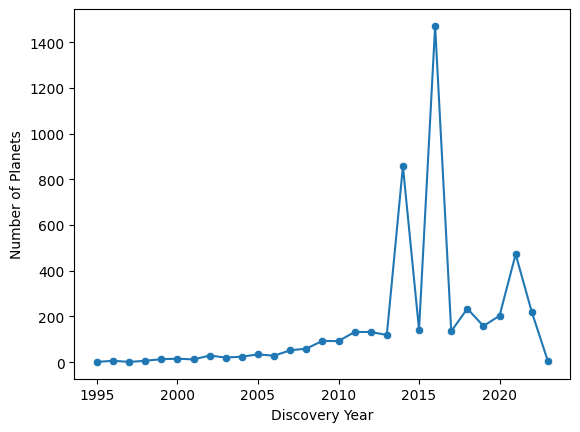

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

year_counts= df['discovery_year'].value_counts().sort_index()
#convert to a dataframe
year_counts= year_counts.reset_index()
year_counts.columns=['discovery_year','planet_count']
#create a scatterplot
sns.scatterplot(data=year_counts, x='discovery_year',y='planet_count')
plt.title=("Number of Planets and their discovery year")
plt.xlabel('Discovery Year')
plt.ylabel('Number of Planets')
#create a straight line to show the improvement
sns.lineplot(data=year_counts,x='discovery_year',y='planet_count')
plt.show()


Show the amount of planet types. We can igore the Neptune-like planets and highlight the gas-giant and earth-like planets. Our own gas-giant (Jupiter) serves as a vaccum that protects us from objects.

In [57]:
print(type(plt.title))

<class 'str'>


<class 'str'>
<class 'str'>


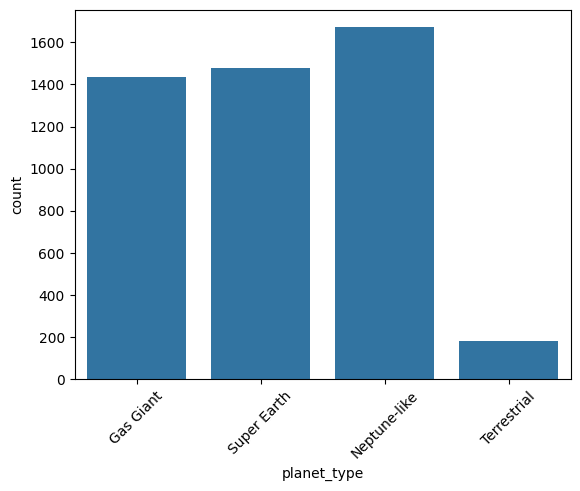

In [58]:
import matplotlib as plyplot
import seaborn as sns 
sns.countplot(data=df,x="planet_type")
plt.xticks(rotation=45)
print(type(plt.title))
print(type(plt.title))
plt.show()

In [59]:
print(df['detection_method'])

0       Radial Velocity
1       Radial Velocity
2       Radial Velocity
3       Radial Velocity
4       Radial Velocity
             ...       
5245            Transit
5246     Direct Imaging
5247    Radial Velocity
5248    Radial Velocity
5249    Radial Velocity
Name: detection_method, Length: 4765, dtype: str
